<a href="https://colab.research.google.com/github/Anbuselvi28042004/my-first-project/blob/main/02_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

import os

ZIP_PATH = '/content/drive/MyDrive/CASIA-B/archive.zip'
DRIVE_WORK_DIR = '/content/drive/MyDrive/CASIA-B/work'  # GEIs, checkpoints, gallery saved here
os.makedirs(DRIVE_WORK_DIR, exist_ok=True)

assert os.path.exists(ZIP_PATH), f"archive.zip not found at {ZIP_PATH}"
print("Drive mounted. Zip found at:", ZIP_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Zip found at: /content/drive/MyDrive/CASIA-B/archive.zip


In [ ]:
# Cell 2 — Install dependencies (all numpy-1.x compatible, pinned together)

!pip install -q \
    "numpy==1.26.4" \
    "scipy==1.11.4" \
    "scikit-learn==1.3.2" \
    "opencv-python-headless==4.9.0.80" \
    "onnxruntime==1.17.3" \
    "ultralytics==8.2.103" \
    "insightface==0.7.3" \
    "xgboost==2.0.3" \
    einops PyYAML tensorboard termcolor tqdm

# Re-pin numpy LAST as a final safety net (no --force-reinstall = fast, no spam)
!pip install -q "numpy==1.26.4"

!pip show numpy scipy scikit-learn | grep -E "Name|Version"
print("Dependencies installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 847.4 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 4.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.1/875.1 kB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.1/297.1 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 10.2 MB/s et

In [ ]:
# Cell 2B — sanity check (run right after installs)
import numpy as np
import cv2
print("numpy:", np.__version__)
print("opencv:", cv2.__version__)

import onnxruntime
print("onnxruntime:", onnxruntime.__version__)

from insightface.app import FaceAnalysis
test_app = FaceAnalysis(name='buffalo_l', providers=['CPUExecutionProvider'])
test_app.prepare(ctx_id=0, det_size=(320, 320))
print("insightface loaded OK")

numpy: 1.26.4
opencv: 4.11.0
onnxruntime: 1.17.3
download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:09<00:00, 30390.16KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (320, 320)
insightface 

In [ ]:
# 3 GPU check+config
import os
import torch

if 'DRIVE_WORK_DIR' not in dir():
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_WORK_DIR = '/content/drive/MyDrive/CASIA-B/work'
    os.makedirs(DRIVE_WORK_DIR, exist_ok=True)
    print("Rebuilt DRIVE_WORK_DIR:", DRIVE_WORK_DIR)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", DEVICE)
if DEVICE == 'cuda':
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

USE_AMP = True

CONFIG = {
    "img_size": 64,
    "batch_size": 32,
    "epochs_gait": 60,
    "epochs_gender": 20,
    "lr_gait": 1e-4,
    "lr_gender": 1e-3,
    "num_workers": 4,
    "drive_work_dir": DRIVE_WORK_DIR,
    "local_data_dir": "/content/casia_b",
    "gei_dir": "/content/drive/MyDrive/CASIA-B/work/GEI",
    "gallery_path": "/content/drive/MyDrive/CASIA-B/work/gallery_embeddings.pkl",
    "gait_ckpt_path": "/content/drive/MyDrive/CASIA-B/work/deepgaitv2_finetuned.pth",
    "gender_ckpt_path": "/content/drive/MyDrive/CASIA-B/work/gender_classifier.pth"
}
os.makedirs(CONFIG["gei_dir"], exist_ok=True)
print(CONFIG)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rebuilt DRIVE_WORK_DIR: /content/drive/MyDrive/CASIA-B/work
Device: cpu
{'img_size': 64, 'batch_size': 32, 'epochs_gait': 60, 'epochs_gender': 20, 'lr_gait': 0.0001, 'lr_gender': 0.001, 'num_workers': 4, 'drive_work_dir': '/content/drive/MyDrive/CASIA-B/work', 'local_data_dir': '/content/casia_b', 'gei_dir': '/content/drive/MyDrive/CASIA-B/work/GEI', 'gallery_path': '/content/drive/MyDrive/CASIA-B/work/gallery_embeddings.pkl', 'gait_ckpt_path': '/content/drive/MyDrive/CASIA-B/work/deepgaitv2_finetuned.pth', 'gender_ckpt_path': '/content/drive/MyDrive/CASIA-B/work/gender_classifier.pth'}


In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
# 4 extract archive
import os
import zipfile
from tqdm import tqdm

# rebuild ZIP_PATH if missing (e.g. after a runtime restart)
if 'ZIP_PATH' not in dir():
    ZIP_PATH = '/content/drive/MyDrive/CASIA-B/archive.zip'
    assert os.path.exists(ZIP_PATH), f"archive.zip not found at {ZIP_PATH}"
    print("Rebuilt ZIP_PATH:", ZIP_PATH)

LOCAL_DATA_DIR = CONFIG["local_data_dir"]
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

if not os.listdir(LOCAL_DATA_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        members = z.namelist()
        for m in tqdm(members, desc="Extracting"):
            z.extract(m, LOCAL_DATA_DIR)
    print("Extraction complete.")
else:
    print("Local data dir already populated, skipping extraction.")

candidates = [d for d in os.listdir(LOCAL_DATA_DIR)]
print("Top-level entries after extraction:", candidates)

Rebuilt ZIP_PATH: /content/drive/MyDrive/CASIA-B/archive.zip
Local data dir already populated, skipping extraction.
Top-level entries after extraction: ['output']


In [ ]:
# 5 verify structure ,index subject /condition/angles
DATA_ROOT = os.path.join(LOCAL_DATA_DIR, 'output')
assert os.path.exists(DATA_ROOT), f"Expected root not found: {DATA_ROOT}"

subjects = sorted(os.listdir(DATA_ROOT))
print(f"Total subjects: {len(subjects)}")
print("Sample subjects:", subjects[:5])

sample_subj = subjects[0]
conditions = sorted(os.listdir(os.path.join(DATA_ROOT, sample_subj)))
print(f"Conditions for subject {sample_subj}:", conditions)

sample_cond = conditions[0]
angles = sorted(os.listdir(os.path.join(DATA_ROOT, sample_subj, sample_cond)))
print(f"Angles for {sample_subj}/{sample_cond}:", angles)

sample_angle = angles[0]
frames = sorted(os.listdir(os.path.join(DATA_ROOT, sample_subj, sample_cond, sample_angle)))
print(f"Frame count in one sequence: {len(frames)}")
print("Sample frame:", frames[0])

Total subjects: 124
Sample subjects: ['001', '002', '003', '004', '005']
Conditions for subject 001: ['bg-01', 'bg-02', 'cl-01', 'cl-02', 'nm-01', 'nm-02', 'nm-03', 'nm-04', 'nm-05', 'nm-06']
Angles for 001/bg-01: ['000', '018', '036', '054', '072', '090', '108', '126', '144', '162', '180']
Frame count in one sequence: 89
Sample frame: 001-bg-01-000-001.png


In [ ]:
# 6 GEI Construction functions
import cv2
import numpy as np

def load_silhouette_sequence(seq_dir, img_size=64):
    """Load all frames in a sequence folder as a list of binary silhouettes."""
    frame_files = sorted(f for f in os.listdir(seq_dir) if f.endswith('.png'))
    sils = []
    for f in frame_files:
        img = cv2.imread(os.path.join(seq_dir, f), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_LINEAR)
        _, img = cv2.threshold(img, 20, 255, cv2.THRESH_BINARY)
        sils.append(img.astype(np.float32) / 255.0)
    return sils

def build_gei(sils):
    """Average a list of aligned binary silhouettes into one Gait Energy Image."""
    if len(sils) == 0:
        return None
    stack = np.stack(sils, axis=0)
    gei = stack.mean(axis=0)
    gei = (gei * 255).astype(np.uint8)
    return gei

def process_sequence(seq_dir, img_size=64):
    sils = load_silhouette_sequence(seq_dir, img_size)
    return build_gei(sils)

In [ ]:
# 7 batch GEI for all subjects,save to drive
skipped = []
built = 0

for subj in tqdm(subjects, desc="Subjects"):
    subj_dir = os.path.join(DATA_ROOT, subj)
    conditions = sorted(os.listdir(subj_dir))
    for cond in conditions:
        cond_dir = os.path.join(subj_dir, cond)
        angles = sorted(os.listdir(cond_dir))
        for angle in angles:
            seq_dir = os.path.join(cond_dir, angle)
            out_dir = os.path.join(CONFIG["gei_dir"], subj, cond)
            out_path = os.path.join(out_dir, f"{angle}.png")

            if os.path.exists(out_path):
                continue  # resume-safe: skip already-built GEIs

            gei = process_sequence(seq_dir, img_size=CONFIG["img_size"])
            if gei is None:
                skipped.append(seq_dir)
                continue

            os.makedirs(out_dir, exist_ok=True)
            cv2.imwrite(out_path, gei)
            built += 1

print(f"GEIs built: {built}")
print(f"Sequences skipped (empty): {len(skipped)}")

Subjects: 100%|██████████| 124/124 [00:04<00:00, 29.22it/s]

GEIs built: 0
Sequences skipped (empty): 0


In [ ]:
# Quick diagnostic — run this now
print("DATA_ROOT:", DATA_ROOT)
print("subjects:", subjects[:5], "... total:", len(subjects))
print("Contents of first subject dir:", os.listdir(os.path.join(DATA_ROOT, subjects[0])))

DATA_ROOT: /content/casia_b/output
subjects: ['001', '002', '003', '004', '005'] ... total: 124
Contents of first subject dir: ['cl-02', 'nm-05', 'nm-04', 'bg-02', 'nm-02', 'bg-01', 'nm-01', 'nm-06', 'nm-03', 'cl-01']


In [ ]:
# Diagnostic 2 — check angles and one actual sequence
subj_dir = os.path.join(DATA_ROOT, subjects[0])
cond = os.listdir(subj_dir)[0]
cond_dir = os.path.join(subj_dir, cond)
print("Condition dir:", cond_dir)
print("Angles:", os.listdir(cond_dir))

angle = os.listdir(cond_dir)[0]
seq_dir = os.path.join(cond_dir, angle)
print("Sequence dir:", seq_dir)
print("Files in sequence:", os.listdir(seq_dir)[:5])

# Try building a GEI directly
test_gei = process_sequence(seq_dir, img_size=CONFIG["img_size"])
print("GEI result:", "None" if test_gei is None else test_gei.shape)

# Check what out_dir Cell 7 was actually writing to
out_dir_check = os.path.join(CONFIG["gei_dir"], subjects[0], cond)
print("Expected out_dir:", out_dir_check)
print("Does gei_dir exist at all?", os.path.exists(CONFIG["gei_dir"]))
print("Contents of gei_dir:", os.listdir(CONFIG["gei_dir"]) if os.path.exists(CONFIG["gei_dir"]) else "MISSING")

Condition dir: /content/casia_b/output/001/cl-02
Angles: ['054', '018', '036', '072', '144', '180', '090', '108', '126', '162', '000']
Sequence dir: /content/casia_b/output/001/cl-02/054
Files in sequence: ['001-cl-02-054-062.png', '001-cl-02-054-019.png', '001-cl-02-054-047.png', '001-cl-02-054-055.png', '001-cl-02-054-060.png']
GEI result: (64, 64)
Expected out_dir: /content/drive/MyDrive/CASIA-B/work/GEI/001/cl-02
Does gei_dir exist at all? True
Contents of gei_dir: ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050', '051', '052', '053', '054', '055', '056', '057', '058', '059', '060', '061', '062', '063', '064', '065', '066', '067', '068', '069', '070', '071', '072', '073', '074', '075', 

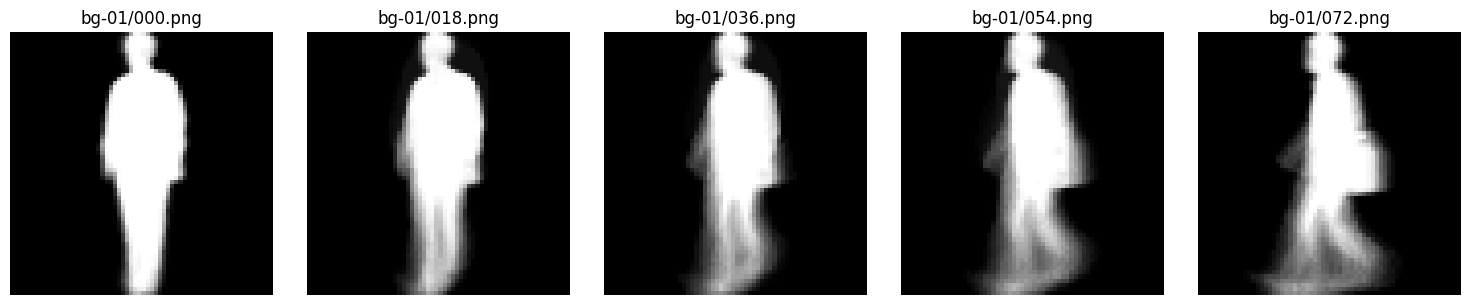

In [ ]:
# 8 visulaize sample GEIs
import matplotlib.pyplot as plt

sample_subj = subjects[0]
sample_gei_dir = os.path.join(CONFIG["gei_dir"], sample_subj)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
count = 0
for cond in sorted(os.listdir(sample_gei_dir)):
    for angle_file in sorted(os.listdir(os.path.join(sample_gei_dir, cond))):
        if count >= 5:
            break
        img = cv2.imread(os.path.join(sample_gei_dir, cond, angle_file), cv2.IMREAD_GRAYSCALE)
        axes[count].imshow(img, cmap='gray')
        axes[count].set_title(f"{cond}/{angle_file}")
        axes[count].axis('off')
        count += 1
    if count >= 5:
        break

plt.tight_layout()
plt.show()

In [ ]:
# 9 build gait gallery from cassia-b
# 9 Build gait gallery from CASIA-B GEIs (per-subject enrolled template)
import pickle

GALLERY_ANGLE = "090"                 # side view, most discriminative for gait
GALLERY_CONDS = ["nm-01", "nm-02"]    # normal walking only, not bg/cl

gallery = {}
for subj in subjects:
    vecs = []
    for cond in GALLERY_CONDS:
        gei_path = os.path.join(CONFIG["gei_dir"], subj, cond, f"{GALLERY_ANGLE}.png")
        if os.path.exists(gei_path):
            img = cv2.imread(gei_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                vecs.append(img.astype(np.float32).flatten() / 255.0)
    if vecs:
        gallery[subj] = np.mean(vecs, axis=0)

print(f"Gallery built for {len(gallery)} / {len(subjects)} subjects")

with open(CONFIG["gallery_path"], "wb") as f:
    pickle.dump(gallery, f)
print("Gallery saved to:", CONFIG["gallery_path"])

Gallery built for 124 / 124 subjects
Gallery saved to: /content/drive/MyDrive/CASIA-B/work/gallery_embeddings.pkl


In [ ]:
# 10 cosine similiarity matcher
# 10 a Cosine similarity matching function
def match_identity(query_gei, gallery, threshold=0.80):
    """Compare a query GEI (uint8 image) against the gallery.
    Returns (subject_id, score) if above threshold, else (None, best_score)."""
    if query_gei is None:
        return None, 0.0
    q = query_gei.astype(np.float32).flatten() / 255.0
    q_norm = q / (np.linalg.norm(q) + 1e-8)

    best_subj, best_score = None, -1.0
    for subj, g in gallery.items():
        g_norm = g / (np.linalg.norm(g) + 1e-8)
        score = float(np.dot(q_norm, g_norm))
        if score > best_score:
            best_subj, best_score = subj, score

    if best_score >= threshold:
        return best_subj, best_score
    return None, best_score

In [ ]:
# Cell 10B — build a test video from real CASIA-B silhouette frames
import cv2, os

test_subj = subjects[10]
test_cond = "nm-01"
test_angle = "090"
seq_dir = os.path.join(DATA_ROOT, test_subj, test_cond, test_angle)
frame_files = sorted(f for f in os.listdir(seq_dir) if f.endswith('.png'))

first_frame = cv2.imread(os.path.join(seq_dir, frame_files[0]))
h, w = first_frame.shape[:2]
out = cv2.VideoWriter('/content/casia_subject_video.mp4', cv2.VideoWriter_fourcc(*'mp4v'), 10, (w, h))
for f in frame_files:
    img = cv2.imread(os.path.join(seq_dir, f))
    out.write(img)
out.release()
print(f"Built video for subject {test_subj}, saved to /content/casia_subject_video.mp4")

Built video for subject 011, saved to /content/casia_subject_video.mp4


In [ ]:
# Cell 10C — gait recognition directly on CASIA-B silhouette video (no YOLO)
cap = cv2.VideoCapture('/content/casia_subject_video.mp4')
fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter('/content/casia_gait_labeled.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

sil_buffer = []
identity_label = "Unknown"

frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    sil = cv2.resize(gray, (CONFIG["img_size"], CONFIG["img_size"]))
    sil = (sil > 20).astype(np.float32)
    sil_buffer.append(sil)

    if len(sil_buffer) >= 20:
        query_gei = build_gei(sil_buffer)
        subj, score = match_identity(query_gei, gallery, threshold=MATCH_THRESHOLD)
        identity_label = f"gallery-{subj}" if subj else "Unknown"
        sil_buffer = []

    label = identity_label
    cv2.rectangle(frame, (0,0), (w-1, h-1), (0,255,0), 3)
    cv2.putText(frame, label, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

    out.write(frame)
    frame_idx += 1

cap.release()
out.release()
print("Done. Saved to: /content/casia_gait_labeled.mp4")

Done. Saved to: /content/casia_gait_labeled.mp4


In [ ]:
# 11 GAIT RECOGNITION ONLY - clean labels like gallery-001
GAIT_BUFFER_SIZE = 20
MATCH_THRESHOLD = 0.80

if 'gallery' not in dir():
    with open(CONFIG["gallery_path"], "rb") as f:
        gallery = pickle.load(f)

if 'yolo_model' not in dir():
    from ultralytics import YOLO
    yolo_model = YOLO('yolov8n-seg.pt')
    print("YOLO model reloaded")



cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out_path = '/content/gait_only_output.mp4'
out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

tracks = {}
next_id = 0
box_colors = [(0,255,0), (0,0,255), (255,0,0), (0,0,0), (255,165,0), (255,0,255)]

def iou(a, b):
    xa, ya = max(a[0], b[0]), max(a[1], b[1])
    xb, yb = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, xb - xa) * max(0, yb - ya)
    area_a = (a[2]-a[0]) * (a[3]-a[1])
    area_b = (b[2]-b[0]) * (b[3]-b[1])
    return inter / (area_a + area_b - inter + 1e-6)

frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = yolo_model(frame, classes=[0], verbose=False)[0]

    if results.masks is not None:
        for box, mask in zip(results.boxes.xyxy.cpu().numpy(), results.masks.data.cpu().numpy()):
            x1, y1, x2, y2 = box.astype(int)

            best_id, best_iou = None, 0.3
            for tid, t in tracks.items():
                score = iou((x1,y1,x2,y2), t['box'])
                if score > best_iou:
                    best_id, best_iou = tid, score

            if best_id is None:
                best_id = next_id
                tracks[best_id] = {'box': (x1,y1,x2,y2), 'sil_buffer': [], 'identity': None}
                next_id += 1

            tracks[best_id]['box'] = (x1,y1,x2,y2)

            mask_resized = cv2.resize(mask, (w, h), interpolation=cv2.INTER_LINEAR)
            sil_crop = mask_resized[max(0,y1):y2, max(0,x1):x2]
            if sil_crop.size > 0:
                sil = cv2.resize(sil_crop, (CONFIG["img_size"], CONFIG["img_size"]),
                                  interpolation=cv2.INTER_LINEAR)
                sil = (sil > 0.5).astype(np.float32)
                tracks[best_id]['sil_buffer'].append(sil)

            if len(tracks[best_id]['sil_buffer']) >= GAIT_BUFFER_SIZE:
                query_gei = build_gei(tracks[best_id]['sil_buffer'])
                subj, score = match_identity(query_gei, gallery, threshold=MATCH_THRESHOLD)
                tracks[best_id]['identity'] = subj
                tracks[best_id]['sil_buffer'] = []

            identity = tracks[best_id]['identity']
            label = f"gallery-{identity}" if identity else "Unknown"
            color = box_colors[best_id % len(box_colors)]

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(frame, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    out.write(frame)
    frame_idx += 1

cap.release()
out.release()
print("Done. Saved to:", out_path)

Using CASIA-B test video: /content/casia_subject_video.mp4
Done. Saved to: /content/gait_only_output.mp4


In [ ]:
# 11 re-encode + preview
from IPython.display import HTML
from base64 import b64encode

!ffmpeg -y -i /content/gait_only_output.mp4 -vcodec libx264 -pix_fmt yuv420p /content/gait_only_output_fixed.mp4

mp4 = open('/content/gait_only_output_fixed.mp4', 'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML(f'<video width=480 controls><source src="{data_url}" type="video/mp4"></video>')

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
!pip install -q numpy==1.26.4

In [ ]:
import numpy as np
import cv2
print(np.__version__, cv2.__version__)

In [ ]:
!pip install -q ultralytics==8.2.103
!pip show ultralytics
!pip install -q onnxruntime
!pip install -q "numpy==1.26.4" ultralytics==8.2.103 onnxruntime insightface==0.7.3 opencv-python-headless

In [ ]:
from google.colab import files
import cv2
import numpy as np
from ultralytics import YOLO
from insightface.app import FaceAnalysis

yolo_model = YOLO('yolov8x-seg.pt')
face_app = FaceAnalysis(name='buffalo_l', providers=['CPUExecutionProvider'])
face_app.prepare(ctx_id=0, det_size=(320, 320))

print("Upload a short video (mp4/avi)")
uploaded = files.upload()
video_path = list(uploaded.keys())[0]
print("Uploaded:", video_path)

In [ ]:
# 10 process video
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out_path = '/content/demo_output.mp4'
out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

tracks = {}
next_id = 0

def iou(a, b):
    xa, ya = max(a[0], b[0]), max(a[1], b[1])
    xb, yb = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, xb - xa) * max(0, yb - ya)
    area_a = (a[2]-a[0]) * (a[3]-a[1])
    area_b = (b[2]-b[0]) * (b[3]-b[1])
    return inter / (area_a + area_b - inter + 1e-6)

frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = yolo_model(frame, classes=[0], verbose=False)[0]

    if results.masks is not None:
        for box in results.boxes.xyxy.cpu().numpy():
            x1, y1, x2, y2 = box.astype(int)

            best_id, best_iou = None, 0.3
            for tid, t in tracks.items():
                score = iou((x1, y1, x2, y2), t['box'])
                if score > best_iou:
                    best_id, best_iou = tid, score

            if best_id is None:
                best_id = next_id
                tracks[best_id] = {'box': (x1, y1, x2, y2), 'gender': None}
                next_id += 1

            tracks[best_id]['box'] = (x1, y1, x2, y2)

            if frame_idx % 10 == 0:
                crop = frame[max(0, y1):y2, max(0, x1):x2]
                if crop.size > 0:
                    faces = face_app.get(crop)
                    if len(faces) > 0:
                        tracks[best_id]['gender'] = 'Male' if faces[0].sex == 'M' else 'Female'

            gender = tracks[best_id]['gender'] or "Detecting..."

            # OpenCV uses BGR, not RGB
            if gender == 'Male':
                color = (255, 0, 0)      # blue
            elif gender == 'Female':
                color = (180, 105, 255)  # pink
            else:
                color = (0, 255, 0)      # green while still detecting

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(frame, f"ID-{best_id} | {gender}", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    out.write(frame)
    frame_idx += 1

cap.release()
out.release()
print(f"Done. Processed {frame_idx} frames -> {out_path}")

In [ ]:
# Re-encode to browser-compatible H.264
!ffmpeg -y -i /content/demo_output.mp4 -vcodec libx264 -pix_fmt yuv420p /content/demo_output_fixed.mp4
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML(f'<video width=480 controls><source src="{data_url}" type="video/mp4"></video>')

In [ ]:
from IPython.display import HTML
from base64 import b64encode

mp4 = open('/content/demo_output_fixed.mp4', 'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML(f'<video width=480 controls><source src="{data_url}" type="video/mp4"></video>')